In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

**Let's First Load The  Superstore dataset**

In [2]:
dataset=pd.read_csv(r"C:\Users\mahes\Desktop\python_projects\train.csv")

In [3]:
dataset.head(5)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


**Lets See the shape of the data**

In [4]:
dataset.shape

(9800, 18)

**Let's Check what are columns are there in superstore dataset**

In [5]:
dataset.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales'],
      dtype='object')

**Let's Check Is there any null values in dataset**

In [6]:
dataset.isna().sum()

Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country           0
City              0
State             0
Postal Code      11
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
dtype: int64

**Drop The Unwanted columns**

In [7]:
dataset.drop(['Row ID','Customer Name','City','Country','Postal Code','Product Name'
              ],axis=1,inplace=True)

**Let's check duplicate value in the dataset and drop duplicates**

In [8]:
dataset.duplicated().sum()

np.int64(1)

In [9]:
dataset.drop_duplicates(inplace=True)

**Let's Check duplicated values in the customer id and order id and drop**

In [10]:
dataset.duplicated(subset=['Product ID','Customer ID','Order ID']).sum()

np.int64(7)

In [11]:
dataset.drop_duplicates(
    subset=['Order ID', 'Product ID', 'Sales'],
    inplace=True
)

**Converting Order Date column from string data type to Date format**

In [12]:
dataset['Order Date']=pd.to_datetime(dataset['Order Date'],errors='coerce')

**Creating Year column from Order Date column**

In [13]:
dataset['Year']=dataset['Order Date'].dt.year

**Create Month column from the Order Date Column**

In [14]:
dataset['Month']=dataset['Order Date'].dt.month_name()

In [15]:
months_order = ['January', 'February', 'March', 'April', 'May', 'June', 
                'July', 'August', 'September', 'October', 'November', 'December']

In [16]:
dataset['Month']=pd.Categorical(dataset['Month'],categories=months_order,ordered=True)

**Replace the null values in the order date column**

In [17]:
dataset['Order Date'] = dataset['Order Date'].fillna(method='ffill')

C:\Users\mahes\AppData\Local\Temp\ipykernel_10880\3149309352.py:1: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  dataset['Order Date'] = dataset['Order Date'].fillna(method='ffill')


**Changing the sales values to the decimal point of 1**

In [18]:
dataset['Sales']=dataset['Sales'].round(1)

C:\Users\mahes\AppData\Local\Temp\ipykernel_10880\4237377508.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  dataset.groupby(['Year','Month'])['Sales'].sum().unstack().plot(kind='bar',figsize=(15,5))


<Axes: xlabel='Year'>

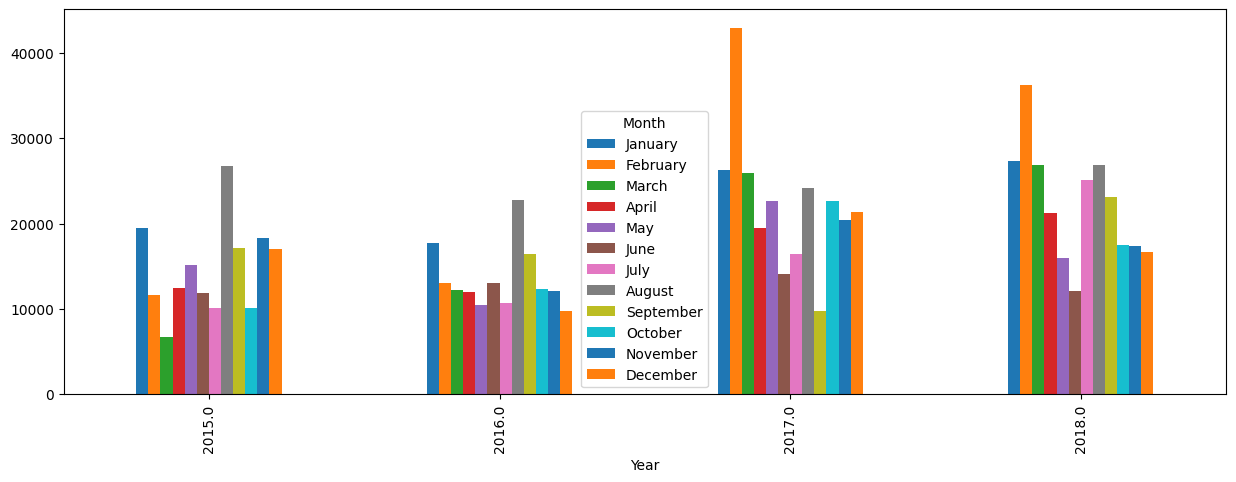

In [19]:
dataset.groupby(['Year','Month'])['Sales'].sum().unstack().plot(kind='bar',figsize=(15,5))

In [20]:
dataset.columns

Index(['Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID',
       'Segment', 'State', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Sales', 'Year', 'Month'],
      dtype='object')

**Showing Visually Categorical Performance Of Sales**

<Axes: ylabel='Category'>

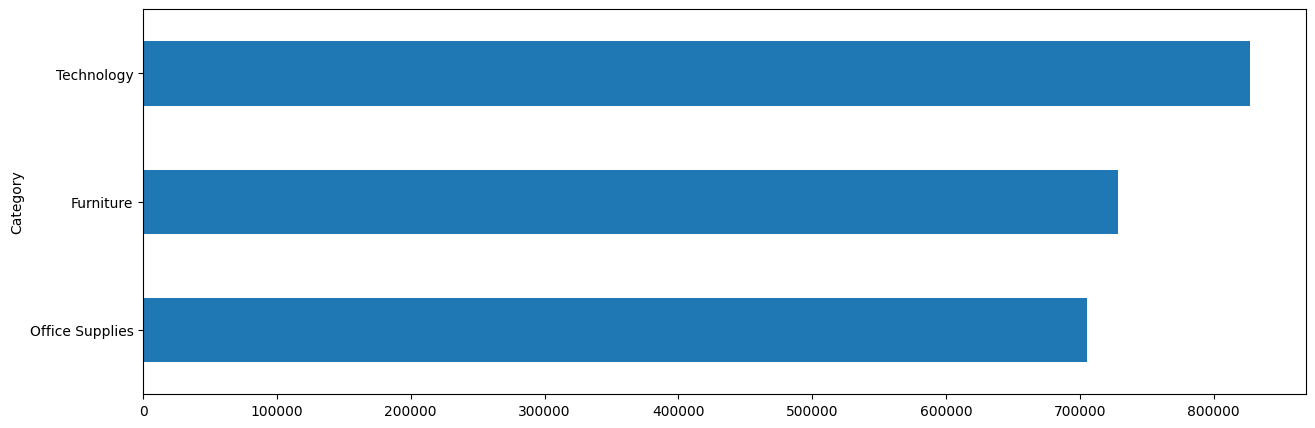

In [21]:
dataset.groupby('Category')['Sales'].sum().sort_values(ascending=True).plot(kind='barh',figsize=(15,5))

**Creating the month-no column**

In [22]:
dataset['Month_No'] = dataset['Order Date'].dt.month

In [23]:
monthly_sales = dataset.groupby(['Year','Month_No','Region','Category'])['Sales'].sum().reset_index()
monthly_sales

,Year,Month_No,Region,Category,Sales
0,2015.0,1,Central,Furniture,6920.2
1,2015.0,1,Central,Office Supplies,2348.1
2,2015.0,1,Central,Technology,468.9
3,2015.0,1,East,Furniture,1005.1
4,2015.0,1,East,Office Supplies,1251.5
...,...,...,...,...,...
551,2018.0,12,South,Furniture,470.0
552,2018.0,12,South,Office Supplies,187.0
553,2018.0,12,West,Furniture,576.3
554,2018.0,12,West,Office Supplies,1974.9


In [24]:
monthly_sales=monthly_sales.sort_values(['Region','Category','Year','Month_No'])

In [25]:
monthly_sales['Quarter']=monthly_sales['Month_No'].apply(lambda x: (x-1)//3 + 1)
monthly_sales

,Year,Month_No,Region,Category,Sales,Quarter
0,2015.0,1,Central,Furniture,6920.2,1
12,2015.0,2,Central,Furniture,98.4,1
24,2015.0,3,Central,Furniture,290.1,1
34,2015.0,4,Central,Furniture,5.5,2
44,2015.0,5,Central,Furniture,617.1,2
...,...,...,...,...,...,...
508,2018.0,8,West,Technology,5276.2,3
520,2018.0,9,West,Technology,1584.8,3
532,2018.0,10,West,Technology,1275.1,4
544,2018.0,11,West,Technology,2258.0,4


In [26]:
#For forecasting first month sales of 2019
last_three_months_sales = monthly_sales[(monthly_sales['Year'] == 2018) & (monthly_sales['Month_No'].isin([10, 11, 12]))]   
last_three_months_sales=last_three_months_sales.sort_values(['Region','Category','Year','Month_No'])
last_three_months_sales.head(5)

,Year,Month_No,Region,Category,Sales,Quarter
521,2018.0,10,Central,Furniture,1636.1,4
533,2018.0,11,Central,Furniture,1118.4,4
545,2018.0,12,Central,Furniture,286.3,4
522,2018.0,10,Central,Office Supplies,1752.6,4
534,2018.0,11,Central,Office Supplies,1443.4,4


In [27]:
monthly_sales['Lag1']=monthly_sales.groupby(['Region','Category'])['Sales'].shift(1)
monthly_sales['Lag2']=monthly_sales.groupby(['Region','Category'])['Sales'].shift(2)


In [28]:
monthly_sales['Rolling3']=(monthly_sales.groupby(['Region','Category'])['Sales']
.rolling(3).mean().reset_index(level=[0,1],drop=True)
).round(1)
monthly_sales

,Year,Month_No,Region,Category,Sales,Quarter,Lag1,Lag2,Rolling3
0,2015.0,1,Central,Furniture,6920.2,1,NaN,NaN,NaN
12,2015.0,2,Central,Furniture,98.4,1,6920.2,NaN,NaN
24,2015.0,3,Central,Furniture,290.1,1,98.4,6920.2,2436.2
34,2015.0,4,Central,Furniture,5.5,2,290.1,98.4,131.3
44,2015.0,5,Central,Furniture,617.1,2,5.5,290.1,304.2
...,...,...,...,...,...,...,...,...,...
508,2018.0,8,West,Technology,5276.2,3,5246.0,332.4,3618.2
520,2018.0,9,West,Technology,1584.8,3,5276.2,5246.0,4035.7
532,2018.0,10,West,Technology,1275.1,4,1584.8,5276.2,2712.0
544,2018.0,11,West,Technology,2258.0,4,1275.1,1584.8,1706.0


In [29]:
monthly_sales['Growth%']=((monthly_sales['Sales']-monthly_sales['Lag1'])/monthly_sales['Lag1']*100).round(1)

In [30]:
monthly_sales['Month_Sin']=np.sin(2*np.pi*monthly_sales['Month_No']/12)

In [31]:
monthly_sales['Month_Cos']=np.cos(2*np.pi*monthly_sales['Month_No']/12)

In [32]:
#Removing the rows with NaN values in Lag1, Lag2, and Rolling3 columns
monthly_sales=monthly_sales.dropna(subset=['Lag1','Lag2','Rolling3'])
monthly_sales

,Year,Month_No,Region,Category,Sales,Quarter,Lag1,Lag2,Rolling3,Growth%,Month_Sin,Month_Cos
24,2015.0,3,Central,Furniture,290.1,1,98.4,6920.2,2436.2,194.8,1.000000e+00,6.123234e-17
34,2015.0,4,Central,Furniture,5.5,2,290.1,98.4,131.3,-98.1,8.660254e-01,-5.000000e-01
44,2015.0,5,Central,Furniture,617.1,2,5.5,290.1,304.2,11120.0,5.000000e-01,-8.660254e-01
56,2015.0,6,Central,Furniture,249.8,2,617.1,5.5,290.8,-59.5,1.224647e-16,-1.000000e+00
68,2015.0,7,Central,Furniture,2701.0,3,249.8,617.1,1189.3,981.3,-5.000000e-01,-8.660254e-01
...,...,...,...,...,...,...,...,...,...,...,...,...
508,2018.0,8,West,Technology,5276.2,3,5246.0,332.4,3618.2,0.6,-8.660254e-01,-5.000000e-01
520,2018.0,9,West,Technology,1584.8,3,5276.2,5246.0,4035.7,-70.0,-1.000000e+00,-1.836970e-16
532,2018.0,10,West,Technology,1275.1,4,1584.8,5276.2,2712.0,-19.5,-8.660254e-01,5.000000e-01
544,2018.0,11,West,Technology,2258.0,4,1275.1,1584.8,1706.0,77.1,-5.000000e-01,8.660254e-01


In [33]:
# make copy of original data for future use
original_data = monthly_sales.copy()

**Import The libraries to train & predict the values**

In [34]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (mean_absolute_error, mean_squared_error, r2_score)

In [35]:
train = monthly_sales[monthly_sales['Year'] < 2018]

In [36]:
train=pd.get_dummies(train,columns=['Region','Category'],drop_first=True)

In [37]:
# Split the data into features and target variable
X_train = train.drop('Sales', axis=1)
y_train = train['Sales']

In [38]:
# create the model
model=RandomForestRegressor(n_estimators=200,random_state=42)

In [39]:
#Train the model
model.fit(X_train,y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease o

In [40]:
test = monthly_sales[monthly_sales['Year'] == 2018]

In [41]:
original_test_data = test.copy()

In [42]:
test=pd.get_dummies(test,columns=['Region','Category'],drop_first=True)

In [43]:
# Split the data into features and target variable
X_test = test.drop('Sales', axis=1)
y_test = test['Sales']

In [44]:
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

In [45]:
test_predictions=model.predict(X_test)

In [46]:
results=original_test_data.loc[test.index].copy()
results['Predicted_Sales']=test_predictions

In [47]:
print("MAE:",round(mean_absolute_error(y_test,test_predictions), 1))
print("RMSE:",round(np.sqrt(mean_squared_error(y_test,test_predictions)), 1))
print("R2 Score:",round(r2_score(y_test,test_predictions), 1))

MAE: 278.6
RMSE: 613.3
R2 Score: 0.9


In [48]:
decisions=(
    results.groupby(['Region','Category']).agg(
    Total_Sales=('Sales','sum'),
    Average_Sales=('Sales','mean'),
    Average_Growth=('Growth%','mean'),
    Predicted_Sales=('Predicted_Sales','mean')
       ).reset_index()   # After Predictions
)

In [49]:
decisions

,Region,Category,Total_Sales,Average_Sales,Average_Growth,Predicted_Sales
0,Central,Furniture,14499.2,1208.266667,28.258333,1229.750167
1,Central,Office Supplies,22040.8,1836.733333,44.916667,1835.143500
2,Central,Technology,19527.5,1627.291667,143.283333,1587.575750
3,East,Furniture,16426.2,1368.850000,100.133333,1349.699208
4,East,Office Supplies,19733.9,1644.491667,45.283333,1721.658208
5,East,Technology,22553.3,1879.441667,101.350000,1816.000875
6,South,Furniture,13684.0,1244.000000,146.218182,1407.381273
7,South,Office Supplies,15608.8,1300.733333,464.766667,1392.453833
8,South,Technology,21790.2,1980.927273,208.618182,1736.088955
9,West,Furniture,37810.9,3150.908333,39.408333,2952.254292


In [50]:
original_data=pd.get_dummies(original_data,columns=['Region','Category'],drop_first=True)

In [51]:
X_train=original_data.drop('Sales',axis=1)
y_train=original_data['Sales']

In [52]:
model_19=RandomForestRegressor(n_estimators=200,random_state=42)
model_19.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease o

In [53]:
future_data=[]

for (region,category), group in last_three_months_sales.groupby(['Region','Category']):
    group =group.sort_values('Month_No')
    if len(group) < 3:
        print(f"Skipping {region} - {category},only {len(group)} rows")
        continue
    oct_sales=group.iloc[0]['Sales']
    nov_sales=group.iloc[1]['Sales']
    dec_sales=group.iloc[2]['Sales']

    future_data.append({
        'Year':2019,
        'Month_No':1,
        'Region':region,
        'Category':category,
        'Lag1':dec_sales,
        'Lag2':nov_sales,
        'Rolling3':(oct_sales+nov_sales+dec_sales)/3,
        'Month_Sin':np.sin(2*np.pi*1/12),
        'Month_Cos':np.cos(2*np.pi*1/12)

    })
future_data=pd.DataFrame(future_data)

Skipping South - Technology,only 2 rows


In [54]:
print(type(future_data))
print(future_data)
print(region,category)
print(group[['Month_No','Sales']])
print(len(group))

<class 'pandas.core.frame.DataFrame'>
    Year  Month_No   Region         Category    Lag1    Lag2     Rolling3  \
0   2019         1  Central        Furniture   286.3  1118.4  1013.600000   
1   2019         1  Central  Office Supplies  1833.5  1443.4  1676.500000   
2   2019         1  Central       Technology  1314.2   305.1  1286.266667   
3   2019         1     East        Furniture  5587.3   392.8  2155.400000   
4   2019         1     East  Office Supplies  1156.6   271.6  1172.166667   
5   2019         1     East       Technology   655.5  1286.2   957.900000   
6   2019         1    South        Furniture   470.0   910.1   481.700000   
7   2019         1    South  Office Supplies   187.0  2142.9  1281.900000   
8   2019         1     West        Furniture   576.3  3927.5  2798.166667   
9   2019         1     West  Office Supplies  1974.9  3278.1  2097.300000   
10  2019         1     West       Technology  2605.3  2258.0  2046.133333   

    Month_Sin  Month_Cos  
0         

In [55]:
future_original_data=future_data.copy()

In [56]:
future_data=pd.get_dummies(future_data,columns=['Region','Category'],drop_first=True)

In [57]:
future_data= future_data.reindex(columns=X_train.columns, fill_value=0)

In [59]:
print(X_train.columns.to_list())
print(future_data.columns.to_list())

['Year', 'Month_No', 'Quarter', 'Lag1', 'Lag2', 'Rolling3', 'Growth%', 'Month_Sin', 'Month_Cos', 'Region_East', 'Region_South', 'Region_West', 'Category_Office Supplies', 'Category_Technology']
['Year', 'Month_No', 'Quarter', 'Lag1', 'Lag2', 'Rolling3', 'Growth%', 'Month_Sin', 'Month_Cos', 'Region_East', 'Region_South', 'Region_West', 'Category_Office Supplies', 'Category_Technology']


In [60]:
future_predictions = model_19.predict(future_data)

In [61]:
future_original_data['Predicted_Sales']=future_predictions

In [ ]:
decisions=(
    results.groupby(['Region','Category']).agg(
    Total_Sales=('Sales','sum'),
    Average_Sales=('Sales','mean'),
    Average_Growth=('Growth%','mean'),
    Predicted_Sales=('Predicted_Sales','mean')
       ).reset_index()   # After Predictions
)

In [62]:
Future_Sales=(
    future_original_data.groupby(['Region','Category']).agg(
    Predicted_Sales=('Predicted_Sales','sum'),
    Average_Sales=('Predicted_Sales','mean')
       ).reset_index()   # After Predictions
)
Future_Sales

,Region,Category,Predicted_Sales,Average_Sales
0,Central,Furniture,582.7870,582.7870
1,Central,Office Supplies,1819.4770,1819.4770
2,Central,Technology,1581.7155,1581.7155
3,East,Furniture,3397.1230,3397.1230
4,East,Office Supplies,1441.8840,1441.8840
5,East,Technology,802.8705,802.8705
6,South,Furniture,502.3775,502.3775
7,South,Office Supplies,630.5065,630.5065
8,West,Furniture,2260.4125,2260.4125
9,West,Office Supplies,2144.6615,2144.6615


In [63]:
#Setting the feature importance
importance=pd.DataFrame({
    'Feature':X_train.columns,
    'Importance':model.feature_importances_
})
importance=importance.sort_values('Importance',ascending=False)
print(importance.round(2))

                     Feature  Importance
5                   Rolling3        0.54
6                    Growth%        0.27
4                       Lag2        0.12
3                       Lag1        0.04
1                   Month_No        0.01
7                  Month_Sin        0.00
8                  Month_Cos        0.00
13       Category_Technology        0.00
0                       Year        0.00
2                    Quarter        0.00
9                Region_East        0.00
12  Category_Office Supplies        0.00
10              Region_South        0.00
11               Region_West        0.00
